# Returns and Corporate-Action Forensics
## Experiment C — Apple’s 4-for-1 Stock Split

### Research question

How can a real stock split create an artificial price collapse, and how
should prices, returns, and investor wealth be represented so that the
corporate action is not mistaken for an economic loss?

### Experiment overview

Apple completed a 4-for-1 stock split on 2020-08-31. The data downloaded
from yfinance are already expressed in post-split share units, even when
`auto_adjust=False`.

In this notebook, we:

1. identify the split event from the vendor action field
2. reconstruct the approximate prices quoted in the historical share unit
3. compare naive and split-aware returns
4. reconstruct the wealth of an investor holding one original share
5. explain why adjusted prices are analytical constructs rather than
   historical executable quotes

# 1. Data provenance and conventions

- Provider: yfinance
- Security: Apple Inc. (`AAPL`)
- Frequency: daily
- Requested period: 2019-01-01 through 2022-01-01
- Actual observations: 2019-01-02 through 2021-12-31
- Download settings:
  - `auto_adjust=False`
  - `actions=True`
  - `repair=False`
- Retrieval script: `scripts/download_yfinance.py`

The returned `Close` field is continuous across Apple’s split and is
therefore already expressed in post-split share units. It is not the
approximately \$500 price displayed immediately before the split.

The returned `Adj Close` field also includes dividend adjustment. I therefore
use the following names:

- `close_split_adjusted`: yfinance `Close`
- `close_total_return_adjusted`: yfinance `Adj Close`
- `close_as_traded_reconstructed`: reconstructed historical quote units

# 2. Reproducible setup

The project root is located by searching upward for `pyproject.toml`.
This prevents notebook behavior from depending on the directory from which
JupyterLab was launched.

Return calculations use the tested functions in
`src/returns_forensics/returns.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display

from returns_forensics.returns import (
    simple_returns,
    split_aware_returns,
)

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root containing pyproject.toml"
    )


project_root = find_project_root(Path.cwd())

raw_path = (
    project_root
    / "data"
    / "raw"
    / "yfinance"
    / "AAPL_2019-01-01_2022-01-01.csv"
)

aapl = pd.read_csv(raw_path)

# 3. Load and audit the dataset

The timestamps are converted to naive New York market dates. We retain the
vendor data unchanged on disk and rename only the columns used in the
analysis.

In [2]:
aapl["date"] = (
    pd.to_datetime(aapl["date"], utc=True)
    .dt.tz_convert("America/New_York")
    .dt.normalize()
    .dt.tz_localize(None)
)

aapl = aapl.rename(
    columns={
        "Close": "close_split_adjusted",
        "Adj Close": "close_total_return_adjusted",
        "Dividends": "cash_dividend",
        "Stock Splits": "split_ratio",
    }
)

assert aapl["date"].is_monotonic_increasing
assert not aapl["date"].duplicated().any()


In [3]:
data_audit = pd.Series(
    {
        "first_date": aapl["date"].min(),
        "last_date": aapl["date"].max(),
        "number_of_rows": len(aapl),
        "split_events": aapl["split_ratio"].gt(0).sum(),
        "dividend_events": aapl["cash_dividend"].gt(0).sum(),
        "duplicate_dates": aapl["date"].duplicated().sum(),
    },
    name="value",
)

display(data_audit.to_frame())

,value
first_date,2019-01-02 00:00:00
last_date,2021-12-31 00:00:00
number_of_rows,757
split_events,1
dividend_events,12
duplicate_dates,0


# 4. Identify the corporate action

The `split_ratio` field contains zero on ordinary dates and the event ratio
on a split date. Apple’s event should appear once, with a value of `4.0`,
meaning four new shares were issued for each old share.

In [17]:
split_events = aapl.loc[
    aapl["split_ratio"].gt(0),
    ["date", "split_ratio"],
]

if len(split_events) != 1:
    raise ValueError(
        f"Expected one split event, found {len(split_events)}"
    )

split_date = split_events["date"].iloc[0]
event_split_ratio = split_events["split_ratio"].iloc[0]

display(split_events)

print(f"Split date: {split_date.date()}")
print(f"Split ratio: {event_split_ratio}-for-1")

,date,split_ratio
419,2020-08-31,4.0


Split date: 2020-08-31
Split ratio: 4.0-for-1


### Interpretation

The vendor records one 4-for-1 split on 2020-08-31. This event date separates
the pre-split share unit from the post-split share unit used throughout the
downloaded close series.

# 5. Reconstruct historical quote units

The downloaded close is expressed in post-split share units throughout the
entire history. To approximate the prices displayed before the split, we
reverse that normalization.

Let $s_u$ be the split ratio on date $u$, with $s_u=1$ on dates without
a split. Define the cumulative factor from splits occurring strictly after
date $t$:

$$
F_t=\prod_{u>t}s_u.
$$

For Apple’s single 4-for-1 split,

$$
F_t=
\begin{cases}
4, & t<\text{2020-08-31},\\
1, & t\geq\text{2020-08-31}.
\end{cases}
$$

The approximate historically quoted close is

$$
P_t^{\mathrm{quoted}}
=
F_tP_t^{\mathrm{split\ adjusted}}.
$$

Therefore, before the event,

$$
P_t^{\mathrm{quoted}}
=
4P_t^{\mathrm{split\ adjusted}},
$$

while on and after the event,

$$
P_t^{\mathrm{quoted}}
=
P_t^{\mathrm{split\ adjusted}}.
$$

The reverse cumulative product includes the current date’s event. The
subsequent one-period shift removes the current event, leaving only splits
strictly after $t$.

In [5]:
split_event_factor = (
    aapl["split_ratio"]
    .replace(0.0, 1.0)
)

inclusive_future_factor = (
    split_event_factor
    .iloc[::-1]
    .cumprod()
    .iloc[::-1]
)

aapl["future_split_factor"] = (
    inclusive_future_factor
    .shift(-1)
    .fillna(1.0)
)

aapl["close_as_traded_reconstructed"] = (
    aapl["close_split_adjusted"]
    * aapl["future_split_factor"]
)

In [6]:
split_index = aapl.index[
    aapl["date"].eq(split_date)
][0]

event_window = aapl.loc[
    split_index - 5 : split_index + 5,
    [
        "date",
        "close_split_adjusted",
        "future_split_factor",
        "close_as_traded_reconstructed",
        "close_total_return_adjusted",
        "split_ratio",
    ],
]

display(event_window)

,date,close_split_adjusted,future_split_factor,close_as_traded_reconstructed,close_total_return_adjusted,split_ratio
414,2020-08-24,125.857498,4.0,503.429993,122.078468,0.0
415,2020-08-25,124.824997,4.0,499.299988,121.076942,0.0
416,2020-08-26,126.522499,4.0,506.089996,122.723488,0.0
417,2020-08-27,125.010002,4.0,500.040009,121.256416,0.0
418,2020-08-28,124.807503,4.0,499.230011,121.059975,0.0
419,2020-08-31,129.039993,1.0,129.039993,125.165382,4.0
420,2020-09-01,134.179993,1.0,134.179993,130.151062,0.0
421,2020-09-02,131.399994,1.0,131.399994,127.454536,0.0
422,2020-09-03,120.879997,1.0,120.879997,117.250420,0.0
423,2020-09-04,120.959999,1.0,120.959999,117.328011,0.0


### Interpretation

Before the split, the downloaded close near \$125 is expressed in
post-split share units. Multiplying by the future split factor reconstructs
historical quotes near \$500.

On the split date, the future split factor changes from four to one. The
reconstructed quoted price therefore falls sharply, while the vendor’s
split-adjusted close remains continuous.

In [7]:
assert aapl.loc[
    aapl["date"] < split_date,
    "future_split_factor",
].eq(4.0).all()

assert aapl.loc[
    aapl["date"] >= split_date,
    "future_split_factor",
].eq(1.0).all()

# 6. Reconcile naive and split-aware returns

The reconstructed quoted-price series changes units on the split date.
An ordinary close-to-close return therefore compares the price of one old
share with the price of one new share.

The naive return is

$$
r_t^{\mathrm{naive}}
=
\frac{P_t^{\mathrm{quoted}}}
     {P_{t-1}^{\mathrm{quoted}}}
-1.
$$

The split-aware return includes the event ratio:

$$
r_t^{\mathrm{split}}
=
\frac{s_tP_t^{\mathrm{quoted}}}
     {P_{t-1}^{\mathrm{quoted}}}
-1.
$$

I compare this with the return from the downloaded split-adjusted close:

$$
r_t^{\mathrm{vendor}}
=
\frac{P_t^{\mathrm{split\ adjusted}}}
     {P_{t-1}^{\mathrm{split\ adjusted}}}
-1.
$$

If the reconstruction is correct,

$$
r_t^{\mathrm{split}}
=
r_t^{\mathrm{vendor}}.
$$

`Adj Close` is included as an additional reference. Around the split date it
matches because no dividend occurs in this event window, although it differs
from `Close` on dividend dates elsewhere in the full sample.

In [8]:
aapl["event_split_factor"] = (
    aapl["split_ratio"].replace(0.0, 1.0)
)

aapl["naive_as_traded_return"] = simple_returns(
    aapl["close_as_traded_reconstructed"]
)

aapl["split_aware_return"] = split_aware_returns(
    raw_prices=aapl["close_as_traded_reconstructed"],
    split_ratios=aapl["event_split_factor"],
)

aapl["split_adjusted_close_return"] = simple_returns(
    aapl["close_split_adjusted"]
)

aapl["total_return_adjusted_close_return"] = simple_returns(
    aapl["close_total_return_adjusted"]
)

aapl["split_return_reconciliation_error"] = (
    aapl["split_aware_return"]
    - aapl["split_adjusted_close_return"]
)

In [9]:
assert aapl.loc[
    split_index,
    "naive_as_traded_return",
] < -0.70

np.testing.assert_allclose(
    aapl["split_aware_return"],
    aapl["split_adjusted_close_return"],
)

In [10]:
return_columns = [
    "date",
    "close_as_traded_reconstructed",
    "close_split_adjusted",
    "split_ratio",
    "naive_as_traded_return",
    "split_aware_return",
    "split_adjusted_close_return",
]

display(aapl.loc[split_index - 2 : split_index + 2, return_columns])

,date,close_as_traded_reconstructed,close_split_adjusted,split_ratio,naive_as_traded_return,split_aware_return,split_adjusted_close_return
417,2020-08-27,500.040009,125.010002,0.0,-0.011954,-0.011954,-0.011954
418,2020-08-28,499.230011,124.807503,0.0,-0.001620,-0.001620,-0.001620
419,2020-08-31,129.039993,129.039993,4.0,-0.741522,0.033912,0.033912
420,2020-09-01,134.179993,134.179993,0.0,0.039833,0.039833,0.039833
421,2020-09-02,131.399994,131.399994,0.0,-0.020718,-0.020718,-0.020718


### Interpretation

The reconstructed quoted price falls from approximately \$499.23 to
\$129.04, producing a naive return of approximately $-74.15\%$.

After accounting for the four new shares received for every old share, the
economic return is approximately $+3.39\%$. This agrees exactly with the
return from the vendor’s split-adjusted close.

# 7. Reconstruct shareholder wealth

A split changes both price per share and the number of shares held. Investor
wealth must therefore be calculated as

$$
W_t=q_tP_t^{\mathrm{quoted}},
$$

where $q_t$ is the number of shares owned per original share.

For this event,

$$
q_t=
\begin{cases}
1, & t<\text{2020-08-31},\\
4, & t\geq\text{2020-08-31}.
\end{cases}
$$

The corresponding wealth return is

$$
r_t^W=\frac{W_t}{W_{t-1}}-1.
$$

It should equal the split-aware return.

In [11]:
aapl["shares_per_original_share"] = 1.0

aapl.loc[
    aapl["date"] >= split_date,
    "shares_per_original_share",
] = event_split_ratio

aapl["wealth_per_original_share"] = (
    aapl["shares_per_original_share"]
    * aapl["close_as_traded_reconstructed"]
)

aapl["wealth_return"] = simple_returns(
    aapl["wealth_per_original_share"]
)

In [12]:
np.testing.assert_allclose(
    aapl["wealth_return"],
    aapl["split_aware_return"],
)

In [13]:
wealth_window = aapl.loc[
    split_index - 2 : split_index + 2,
    [
        "date",
        "close_as_traded_reconstructed",
        "shares_per_original_share",
        "wealth_per_original_share",
        "naive_as_traded_return",
        "wealth_return",
        "split_aware_return",
    ],
]

display(wealth_window)

,date,close_as_traded_reconstructed,shares_per_original_share,wealth_per_original_share,naive_as_traded_return,wealth_return,split_aware_return
417,2020-08-27,500.040009,1.0,500.040009,-0.011954,-0.011954,-0.011954
418,2020-08-28,499.230011,1.0,499.230011,-0.001620,-0.001620,-0.001620
419,2020-08-31,129.039993,4.0,516.159973,-0.741522,0.033912,0.033912
420,2020-09-01,134.179993,4.0,536.719971,0.039833,0.039833,0.039833
421,2020-09-02,131.399994,4.0,525.599976,-0.020718,-0.020718,-0.020718


### Interpretation

The reconstructed quoted price falls from approximately \$499.23 to
\$129.04 because the price is expressed per share and one old share is replaced by four new shares

The investor's wealth does not experience this mechanical decline. One
pre-split share worth \$499.23 becomes four post-split shares worth
approximately \$516.16 in total. Apple also experienced an ordinary positive
market move across the event, producing an economic return of approximately
3.39%.

The naive return is therefore invalid because it compares prices expressed
in different share units.

# 8. Visualizing the unit change

The reconstructed as-traded price is expressed in the historical share unit.
It therefore falls when one old share becomes four new shares.

The split-adjusted close rewrites the earlier history into post-split share
units, creating a continuous analytical series. It is useful for return
analysis but does not represent the prices displayed to investors before the
split.

The lower panel compares the invalid naive return with the economically
correct split-aware return.

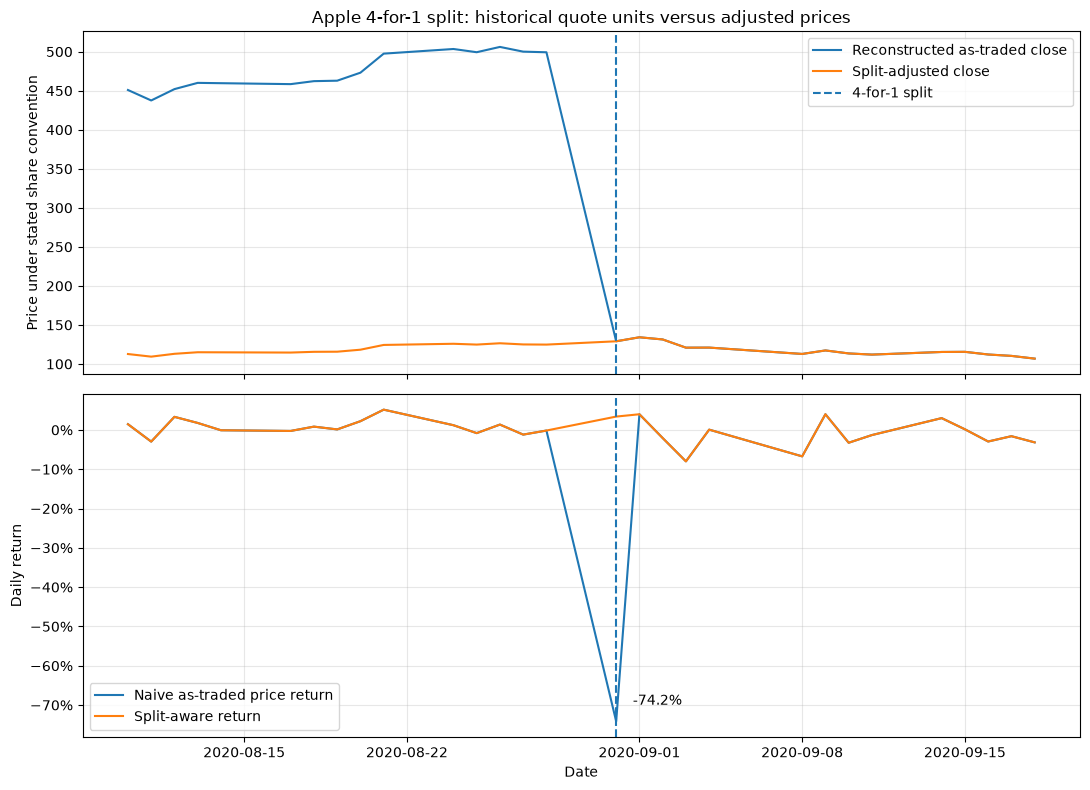

In [14]:
plot_window = aapl.loc[
    aapl["date"].between("2020-08-10", "2020-09-18")
].copy()

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "aapl_real_split_forensics.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 8),
    sharex=True,
)

axes[0].plot(
    plot_window["date"],
    plot_window["close_as_traded_reconstructed"],
    label="Reconstructed as-traded close",
)

axes[0].plot(
    plot_window["date"],
    plot_window["close_split_adjusted"],
    label="Split-adjusted close",
)

axes[0].axvline(
    split_date,
    linestyle="--",
    label="4-for-1 split",
)

axes[0].set_title(
    "Apple 4-for-1 split: historical quote units versus adjusted prices"
)
axes[0].set_ylabel("Price under stated share convention")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    plot_window["date"],
    plot_window["naive_as_traded_return"],
    label="Naive as-traded price return",
)

axes[1].plot(
    plot_window["date"],
    plot_window["split_aware_return"],
    label="Split-aware return",
)
axes[1].annotate(
    f"{aapl.loc[split_index, 'naive_as_traded_return']:.1%}",
    xy=(
        split_date,
        aapl.loc[split_index, "naive_as_traded_return"],
    ),
    xytext=(12, 12),
    textcoords="offset points",
)
axes[1].axvline(
    split_date,
    linestyle="--",
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily return")
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 9. Evidence summary

The following table collects the central numerical evidence from the
experiment and is saved as a reproducible report artifact.

In [15]:
split_evidence = pd.Series(
    {
        "split_date": split_date,
        "split_ratio": event_split_ratio,
        "previous_as_traded_close": (
            aapl.loc[
                split_index - 1,
                "close_as_traded_reconstructed",
            ]
        ),
        "split_date_as_traded_close": (
            aapl.loc[
                split_index,
                "close_as_traded_reconstructed",
            ]
        ),
        "naive_price_return": (
            aapl.loc[
                split_index,
                "naive_as_traded_return",
            ]
        ),
        "split_aware_return": (
            aapl.loc[
                split_index,
                "split_aware_return",
            ]
        ),
        "wealth_before_split": (
            aapl.loc[
                split_index - 1,
                "wealth_per_original_share",
            ]
        ),
        "wealth_after_split": (
            aapl.loc[
                split_index,
                "wealth_per_original_share",
            ]
        ),
    },
    name="value",
)

display(split_evidence.to_frame())

,value
split_date,2020-08-31 00:00:00
split_ratio,4.0
previous_as_traded_close,499.230011
split_date_as_traded_close,129.039993
naive_price_return,-0.741522
split_aware_return,0.033912
wealth_before_split,499.230011
wealth_after_split,516.159973


In [16]:
table_path = (
    project_root
    / "reports"
    / "tables"
    / "aapl_real_split_evidence.csv"
)

table_path.parent.mkdir(parents=True, exist_ok=True)
split_evidence.to_frame().to_csv(table_path)

# 10. Experiment C conclusion

Apple's 4-for-1 split changed the number of shares and the quoted price per
share but did not reduce shareholder wealth.

The approximate historical quoted close fell from \$499.23 before the split
to \$129.04 on the split date. A naive close-to-close calculation therefore
reported a return of approximately $-74.15\%$. That calculation is invalid
because the two prices are expressed in different share units.

An investor holding one original share instead received four post-split
shares. The value of the position increased from approximately \$499.23 to
\$516.16, corresponding to an economic return of approximately $3.39\%$.
The split-aware return agrees exactly with the return calculated from
yfinance's split-adjusted close.

Back-adjusted prices are therefore useful analytical constructs, but they do
not represent the prices that were historically displayed before the split.

# 11. Limitations

- The historical as-traded price is reconstructed from yfinance’s
  split-adjusted close and reported split ratio. It is not an independently
  observed archival quote series.
- The analysis considers one split and one security.
- Vendor data may be revised after the original historical date.
- The close-to-close return spans ordinary market movement in addition to
  the split mechanics. The \(3.39\%\) economic return is Apple’s observed
  market return across the interval, not a return caused by the split.
- Adjusted prices are appropriate for return continuity but should not be
  treated as historical executable prices.